## Softmax Regression
### Implemenation of <i>classic<i> softmax regression (multinomial logistic regression)

#### Imports

In [4]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

#### Preparing the dataset

In [124]:
##########################
### DATASET
##########################

df = pd.read_csv("iris.data", header=None, index_col=None)
df.columns = ['x1', 'x2', 'x3', 'x4', 'y']

In [125]:
df['y'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [126]:
d = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2,
}
df['y'] = df['y'].map(d)

In [127]:
df['y'].unique()

array([0, 1, 2])

In [22]:
# Assigning features and target
X = torch.tensor(df[['x2', 'x4']].values, dtype=torch.float)
y = torch.tensor(df[['y']].values, dtype=torch.float)

In [23]:
X.shape, y.shape

(torch.Size([150, 2]), torch.Size([150, 1]))

In [98]:
# Shuffling & train/test split

torch.manual_seed(123)
idx = torch.randperm(y.shape[0])
X, y = X[idx], y[idx]

In [128]:
X = torch.tensor(df[['x2', 'x4']].values, dtype=torch.float)
y = torch.tensor(df['y'].values, dtype=torch.int)

# Shuffling & train/test split

torch.manual_seed(123)
shuffle_idx = torch.randperm(y.size(0), dtype=torch.long)

X, y = X[shuffle_idx], y[shuffle_idx]

percent80 = int(shuffle_idx.size(0)*0.8)

X_train, X_test = X[shuffle_idx[:percent80]], X[shuffle_idx[percent80:]]
y_train, y_test = y[shuffle_idx[:percent80]], y[shuffle_idx[percent80:]]

# Normalize (mean zero, unit variance)

mu, sigma = X_train.mean(dim=0), X_train.std(dim=0)
X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma


#### Low level implementation with manual gradient

In [129]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [130]:
def to_onehot(y, num_classes):
    y_onehot = torch.FloatTensor(y.size(0), num_classes)
    y_onehot.zero_()
    y_cpu = y.to(torch.device('cpu'))
    y_onehot.scatter_(1, y_cpu.view(-1, 1).long(), 1).float()
    return y_onehot.to(DEVICE)

def softmax(z):
    return (torch.exp(z.t()) / torch.sum(torch.exp(z), dim=1)).t()
                    
def cross_entropy(softmax, y_target):
    return -torch.sum(torch.log(softmax) * (y_target), dim=1)

In [131]:
class SoftmaxRegression1():
    def __init__(self, num_features, num_classes):
        self.num_features = num_features
        self.num_classes = num_classes
        self.weights = torch.zeros(num_classes, num_features, # h x m
                                   dtype=torch.float32, device=DEVICE)
        self.bias = torch.zeros(num_classes, dtype=torch.float32, device=DEVICE) # h

    def forward(self, x):
        logits = torch.mm(x, self.weights.t()) + self.bias # net inputs
        probas = softmax(logits) # activations
        return logits, probas
        
    def backward(self, x, y, probas):  
        grad_loss_wrt_w = -torch.mm(x.t(), y - probas).t()
        grad_loss_wrt_b = -torch.sum(y - probas)
        return grad_loss_wrt_w, grad_loss_wrt_b
            
    def predict_labels(self, x):
        logits, probas = self.forward(x)
        labels = torch.argmax(probas, dim=1)
        return labels    
            
    def evaluate(self, x, y):
        labels = self.predict_labels(x).float()
        accuracy = torch.sum(labels.view(-1) == y.float()).item() / y.size(0)
        return accuracy
    
    def train(self, x, y, num_epochs, learning_rate=0.01):
        epoch_cost = []
        for e in range(num_epochs):
            
            y_onehot = to_onehot(y, num_classes=self.num_classes)
            
            #### Compute outputs ####
            logits, probas = self.forward(x)
            
            #### Compute gradients ####
            grad_w, grad_b = self.backward(x, y_onehot, probas)

            #### Update weights ####
            self.weights -= learning_rate * grad_w / y.size(0)
            self.bias -= learning_rate * grad_b / y.size(0)
            
            #### Logging ####
            logits, probas = self.forward(x)
            cost = torch.mean(cross_entropy(probas, y_onehot))
            print('Epoch: %03d' % (e+1), end="")
            print(' | Train ACC: %.3f' % self.evaluate(x, y), end="")
            print(' | Cost: %.3f' % cost)
            epoch_cost.append(cost)
        return epoch_cost

In [132]:
X_train = X_train.to(DEVICE)
y_train = y_train.to(DEVICE)

In [133]:
model0 = SoftmaxRegression0(num_features=2, num_classes=3)

In [134]:
epoch_cost = model0.train(X_train, y_train, num_epochs=100, learning_rate=0.1)
print("\nModel parameters:")
print("  Weight: %s" % model0.weights)
print("  Bias: %s" % model0.bias)

Epoch: 001 | Train ACC: 0.867 | Cost: 1.055
Epoch: 002 | Train ACC: 0.867 | Cost: 1.016
Epoch: 003 | Train ACC: 0.867 | Cost: 0.979
Epoch: 004 | Train ACC: 0.858 | Cost: 0.945
Epoch: 005 | Train ACC: 0.858 | Cost: 0.914
Epoch: 006 | Train ACC: 0.858 | Cost: 0.886
Epoch: 007 | Train ACC: 0.858 | Cost: 0.859
Epoch: 008 | Train ACC: 0.858 | Cost: 0.835
Epoch: 009 | Train ACC: 0.858 | Cost: 0.812
Epoch: 010 | Train ACC: 0.858 | Cost: 0.791
Epoch: 011 | Train ACC: 0.858 | Cost: 0.772
Epoch: 012 | Train ACC: 0.858 | Cost: 0.754
Epoch: 013 | Train ACC: 0.858 | Cost: 0.737
Epoch: 014 | Train ACC: 0.858 | Cost: 0.722
Epoch: 015 | Train ACC: 0.858 | Cost: 0.707
Epoch: 016 | Train ACC: 0.858 | Cost: 0.693
Epoch: 017 | Train ACC: 0.858 | Cost: 0.680
Epoch: 018 | Train ACC: 0.858 | Cost: 0.668
Epoch: 019 | Train ACC: 0.858 | Cost: 0.657
Epoch: 020 | Train ACC: 0.858 | Cost: 0.646
Epoch: 021 | Train ACC: 0.858 | Cost: 0.636
Epoch: 022 | Train ACC: 0.858 | Cost: 0.627
Epoch: 023 | Train ACC: 0.858 | 

#### Evaluating the model

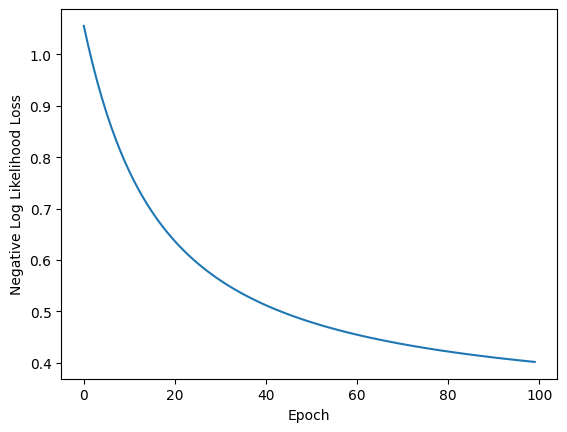

In [135]:
plt.plot(epoch_cost)
plt.ylabel("Negative Log Likelihood Loss")
plt.xlabel("Epoch")
plt.show()

In [136]:
X_test = X_test.to(DEVICE)
y_test = y_test.to(DEVICE)

In [137]:
test_acc = model0.evaluate(X_test, y_test)

In [138]:
print("Test set accuracy: %.2f%%" % (test_acc*100))

Test set accuracy: 80.00%
